## Preprocoessing



**Load data**

In [3]:
import numpy as np
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

In [3]:
#Load data 
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "Data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

ACCELEROMETER_PATH = PROJECT_ROOT  / "New folder (2)" / "Phones_accelerometer.csv"
GYROSCOPE_PATH = PROJECT_ROOT  / "New folder (2)" / "Phones_gyroscope.csv"
db_accelerometer= pd.read_csv(ACCELEROMETER_PATH)
db_gyroscope= pd.read_csv(GYROSCOPE_PATH)
display(db_accelerometer.head())
display(db_gyroscope.head())

,Index,Arrival_Time,Creation_Time,x,y,z,User,Model,Device,gt
0,0,1424696633908,1424696631913248572,-5.958191,0.688065,8.135345,a,nexus4,nexus4_1,stand
1,1,1424696633909,1424696631918283972,-5.952240,0.670212,8.136536,a,nexus4,nexus4_1,stand
2,2,1424696633918,1424696631923288855,-5.995087,0.653549,8.204376,a,nexus4,nexus4_1,stand
3,3,1424696633919,1424696631928385290,-5.942718,0.676163,8.128204,a,nexus4,nexus4_1,stand
4,4,1424696633929,1424696631933420691,-5.991516,0.641647,8.135345,a,nexus4,nexus4_1,stand


,Index,Arrival_Time,Creation_Time,x,y,z,User,Model,Device,gt
0,0,1424696633909,1424696631914042029,0.013748,-0.000626,-0.023376,a,nexus4,nexus4_1,stand
1,1,1424696633909,1424696631919046912,0.014816,-0.001694,-0.022308,a,nexus4,nexus4_1,stand
2,2,1424696633918,1424696631924051794,0.015884,-0.001694,-0.021240,a,nexus4,nexus4_1,stand
3,3,1424696633919,1424696631929117712,0.016953,-0.003830,-0.020172,a,nexus4,nexus4_1,stand
4,4,1424696633928,1424696631934214148,0.015884,-0.007034,-0.020172,a,nexus4,nexus4_1,stand


Check for null values

In [4]:
print("Null values in db_accelerometer preview:")
print(db_accelerometer.isnull().sum())
print("Null values in db_gyroscope preview:")
print(db_gyroscope.isnull().sum())

Null values in db_accelerometer preview:
Index                  0
Arrival_Time           0
Creation_Time          0
x                      0
y                      0
z                      0
User                   0
Model                  0
Device                 0
gt               1783200
dtype: int64
Null values in db_gyroscope preview:
Index                  0
Arrival_Time           0
Creation_Time          0
x                      0
y                      0
z                      0
User                   0
Model                  0
Device                 0
gt               1869627
dtype: int64


Resolve null values by deleting the rows

In [5]:
db_accelerometer = db_accelerometer[
    db_accelerometer["gt"].notna()
    & (db_accelerometer["gt"].astype(str).str.strip().str.lower() != "null")
].copy()

db_gyroscope = db_gyroscope[
    db_gyroscope["gt"].notna()
    & (db_gyroscope["gt"].astype(str).str.strip().str.lower() != "null")
].copy()


In [11]:
print("Null values in db_accelerometer preview:")
print(db_accelerometer.isnull().sum())
print("Null values in db_gyroscope preview:")
print(db_gyroscope.isnull().sum())

Null values in db_accelerometer preview:
Index            0
Arrival_Time     0
Creation_Time    0
x                0
y                0
z                0
User             0
Model            0
Device           0
gt               0
dtype: int64
Null values in db_gyroscope preview:
Index            0
Arrival_Time     0
Creation_Time    0
x                0
y                0
z                0
User             0
Model            0
Device           0
gt               0
dtype: int64


### No null values :) 
### Now we save the processed data

In [6]:
from pathlib import Path

out_dir = Path("processed")
out_dir.mkdir(parents=True, exist_ok=True)

db_accelerometer.to_csv(out_dir / "phones_accelerometer_clean.csv", index=False)
db_gyroscope.to_csv(out_dir / "phones_gyroscope_clean.csv", index=False)


# Check Class imbalance

Class counts for accelerometer:


,count
gt,
walk,2192401
sit,1991919
stand,1851492
bike,1845557
stairsup,1782010
stairsdown,1615896


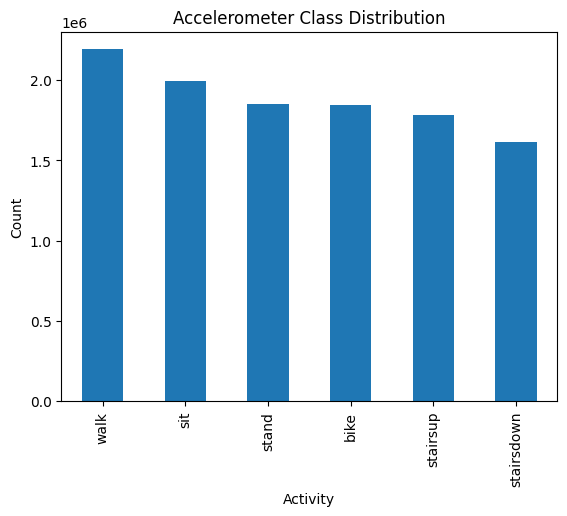

Class counts for gyroscope:


,count
gt,
walk,2350429
sit,2218501
stand,2024206
bike,1911730
stairsup,1884306
stairsdown,1673833


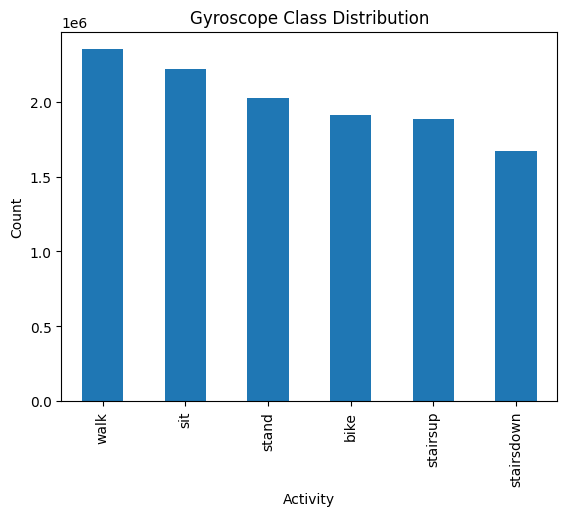

In [7]:
# Check class imbalance for accelerometer data
acc_class_counts = db_accelerometer['gt'].value_counts()
print("Class counts for accelerometer:")
display(acc_class_counts.to_frame())

# Plot
acc_class_counts.plot(kind='bar', title='Accelerometer Class Distribution')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.show()

# Check class imbalance for gyroscope data
gyro_class_counts = db_gyroscope['gt'].value_counts()
print("Class counts for gyroscope:")
display(gyro_class_counts.to_frame())

# Plot
gyro_class_counts.plot(kind='bar', title='Gyroscope Class Distribution')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.show()

In [8]:
# Count users for accelerometer data
acc_user_counts = db_accelerometer['User'].value_counts()
print("User counts for accelerometer:")
display(acc_user_counts.to_frame())

# Count users for gyroscope data
gyro_user_counts = db_gyroscope['User'].value_counts()
print("User counts for gyroscope:")
display(gyro_user_counts.to_frame())

User counts for accelerometer:


,count
User,
i,1342007
b,1320280
e,1310856
g,1278593
d,1223857
h,1223093
a,1218871
c,1188186
f,1173532


User counts for gyroscope:


,count
User,
i,1453955
e,1422338
b,1420750
g,1387361
d,1331326
a,1329103
h,1322948
c,1282412
f,1112812


Classes are balanced we good :)

# Windowing 
#### 1-For windowing we need to first sort it by time and user since it is a time serires 
#### 2- Segment them per user
#### 3- For each user we window that 

In [9]:
# Sort by User and Creation_Time
db_accelerometer.sort_values(by=['User', 'Creation_Time'], inplace=True)
db_gyroscope.sort_values(by=['User', 'Creation_Time'], inplace=True)



In [10]:
from collections import Counter
# Segmenting each user's time series into  windows of 100 samples
Window_size = 100

def segment_har(df, window_size=100, sensor_cols=('x', 'y', 'z'), user_col='User',
                time_col='Creation_Time', label_col='gt'):
    """
    Segment HAR data by user into non-overlapping windows.
    Returns:
      X: np.ndarray, shape (num_windows, window_size, num_features)
      y: np.ndarray, shape (num_windows,)
    """
    windows = []
    labels = []

    for user, user_df in df.groupby(user_col, sort=False):
        # sort each user time series by timestamp
        user_df = user_df.sort_values(time_col)

        n_samples = len(user_df)
        n_windows = n_samples // window_size  # non-overlapping

        if n_windows == 0:
            continue

        trimmed = user_df.iloc[: n_windows * window_size]

        # windowed sensor values
        arr = trimmed[list(sensor_cols)].to_numpy()
        arr = arr.reshape((n_windows, window_size, len(sensor_cols)))
        windows.append(arr)

        # windowed labels for majority voting
        label_chunks = trimmed[label_col].to_numpy().reshape((n_windows, window_size))
        window_labels = [Counter(chunk).most_common(1)[0][0] for chunk in label_chunks]
        labels.extend(window_labels)

    if not windows:
        X = np.empty((0, window_size, len(sensor_cols)), dtype=np.float32)
        y = np.empty((0,), dtype=object)
    else:
        X = np.vstack(windows)
        y = np.array(labels)

    return X, y


# apply to accelerometer data
X_acc, y_acc = segment_har(db_accelerometer, window_size=Window_size)

print("X_acc shape:", X_acc.shape)
print("y_acc shape:", y_acc.shape)
print("Sample label distribution:")
print(pd.Series(y_acc).value_counts())

X_acc shape: (112787, 100, 3)
y_acc shape: (112787,)
Sample label distribution:
walk          21824
sit           19661
bike          18743
stand         18365
stairsup      17918
stairsdown    16276
Name: count, dtype: int64


In [11]:
# apply to gyroscope data
X_gyro, y_gyro = segment_har(db_gyroscope, window_size=Window_size)
print("X_gyro shape:", X_gyro.shape)
print("y_gyro shape:", y_gyro.shape)
print("Sample label distribution:")
print(pd.Series(y_gyro).value_counts())

X_gyro shape: (120627, 100, 3)
y_gyro shape: (120627,)
Sample label distribution:
walk          23505
sit           22105
stand         20417
bike          19020
stairsup      18836
stairsdown    16744
Name: count, dtype: int64


# Feature extraction
##### We will be using Nerual Networks for that 

In [17]:
# ===== NN Feature Extraction Helpers (same core structure as Model/Feature_extraction.ipynb, cleaned) =====

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility + device
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def encode_labels(y):
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(np.asarray(y))
    return y_encoded.astype(np.int64), encoder


def split_data(X, y_encoded, test_size=0.20, valid_size=0.20, random_state=SEED):
    idx = np.arange(len(X))

    train_idx, test_idx = train_test_split(
        idx, test_size=test_size, random_state=random_state, stratify=y_encoded
    )

    train_idx, valid_idx = train_test_split(
        train_idx, test_size=valid_size, random_state=random_state, stratify=y_encoded[train_idx]
    )

    splits = {}
    for name, split_idx in {"train": train_idx, "valid": valid_idx, "test": test_idx}.items():
        splits[name] = {"X": X[split_idx], "y": y_encoded[split_idx]}
    return splits


def scale_windows(train_X, valid_X, test_X):
    scaler = StandardScaler()
    n_channels = train_X.shape[-1]

    train_flat = train_X.reshape(-1, n_channels)
    valid_flat = valid_X.reshape(-1, n_channels)
    test_flat = test_X.reshape(-1, n_channels)

    train_scaled = scaler.fit_transform(train_flat).reshape(train_X.shape).astype(np.float32)
    valid_scaled = scaler.transform(valid_flat).reshape(valid_X.shape).astype(np.float32)
    test_scaled = scaler.transform(test_flat).reshape(test_X.shape).astype(np.float32)

    return train_scaled, valid_scaled, test_scaled, scaler


def flatten_windows(X):
    return X.reshape(X.shape[0], -1).astype(np.float32)


class SimpleFeatureExtractor(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dims=(128, 64)):
        super().__init__()
        self.hidden_layers = nn.ModuleList()
        prev_dim = input_dim
        for h in hidden_dims:
            self.hidden_layers.append(nn.Linear(prev_dim, h))
            prev_dim = h
        self.output_layer = nn.Linear(prev_dim, num_classes)

    def forward_features(self, x):
        for layer in self.hidden_layers:
            x = torch.relu(layer(x))
        return x

    def forward(self, x):
        features = self.forward_features(x)
        return self.output_layer(features)


def make_loader(X, y, batch_size=256, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_model(model, train_loader, valid_loader, epochs=8, learning_rate=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses, train_true, train_pred = [], [], []

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            train_true.extend(yb.detach().cpu().numpy())
            train_pred.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())

        model.eval()
        valid_losses, valid_true, valid_pred = [], [], []

        with torch.no_grad():
            for xb, yb in valid_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)

                valid_losses.append(loss.item())
                valid_true.extend(yb.detach().cpu().numpy())
                valid_pred.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())

        history.append(
            {
                "epoch": epoch,
                "train_loss": float(np.mean(train_losses)),
                "valid_loss": float(np.mean(valid_losses)),
                "train_accuracy": float(accuracy_score(train_true, train_pred)),
                "valid_accuracy": float(accuracy_score(valid_true, valid_pred)),
            }
        )

    return pd.DataFrame(history)


def extract_hidden_features(model, X_flat, batch_size=512):
    model.eval()
    feats = []
    loader = DataLoader(torch.tensor(X_flat, dtype=torch.float32), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            batch_feats = model.forward_features(xb)
            feats.append(batch_feats.cpu().numpy())
    return np.vstack(feats).astype(np.float32)


def predict_classes(model, X_flat, batch_size=512):
    model.eval()
    preds = []
    loader = DataLoader(torch.tensor(X_flat, dtype=torch.float32), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            preds.append(torch.argmax(logits, dim=1).cpu().numpy())
    return np.concatenate(preds)


def run_feature_extraction_from_windows(
    X_windows,
    y_labels,
    hidden_dims=(128, 64),
    batch_size=256,
    epochs=8,
    learning_rate=1e-3,
):
    # X_windows must be shape: (num_windows, window_size, num_channels)
    if X_windows.ndim != 3:
        raise ValueError(f"Expected 3D X_windows, got shape {X_windows.shape}")

    y_encoded, encoder = encode_labels(y_labels)
    splits = split_data(X_windows, y_encoded)

    X_train, X_valid, X_test, scaler = scale_windows(
        splits["train"]["X"], splits["valid"]["X"], splits["test"]["X"]
    )

    X_train_flat = flatten_windows(X_train)
    X_valid_flat = flatten_windows(X_valid)
    X_test_flat = flatten_windows(X_test)

    model = SimpleFeatureExtractor(
        input_dim=X_train_flat.shape[1],
        num_classes=len(encoder.classes_),
        hidden_dims=hidden_dims,
    ).to(DEVICE)

    train_loader = make_loader(X_train_flat, splits["train"]["y"], batch_size=batch_size, shuffle=True)
    valid_loader = make_loader(X_valid_flat, splits["valid"]["y"], batch_size=batch_size, shuffle=False)

    history_df = train_model(
        model=model,
        train_loader=train_loader,
        valid_loader=valid_loader,
        epochs=epochs,
        learning_rate=learning_rate,
    )

    X_train_feat = extract_hidden_features(model, X_train_flat)
    X_valid_feat = extract_hidden_features(model, X_valid_flat)
    X_test_feat = extract_hidden_features(model, X_test_flat)

    y_train_pred = predict_classes(model, X_train_flat)
    y_valid_pred = predict_classes(model, X_valid_flat)
    y_test_pred = predict_classes(model, X_test_flat)

    print("Window input shape:", X_windows.shape)
    print("Train flattened shape:", X_train_flat.shape)
    print("Feature shapes:", X_train_feat.shape, X_valid_feat.shape, X_test_feat.shape)
    print(f"NN Train Accuracy: {accuracy_score(splits['train']['y'], y_train_pred):.4f}")
    print(f"NN Valid Accuracy: {accuracy_score(splits['valid']['y'], y_valid_pred):.4f}")
    print(f"NN Test  Accuracy: {accuracy_score(splits['test']['y'], y_test_pred):.4f}")

    return {
        "model": model,
        "history": history_df,
        "label_encoder": encoder,
        "scaler": scaler,
        "splits": splits,

        "X_train_flat": X_train_flat,
        "X_valid_flat": X_valid_flat,
        "X_test_flat": X_test_flat,

        "X_train_feat": X_train_feat,
        "X_valid_feat": X_valid_feat,
        "X_test_feat": X_test_feat,

        "y_train": splits["train"]["y"],
        "y_valid": splits["valid"]["y"],
        "y_test": splits["test"]["y"],
    }


In [18]:
# Extract features for gyroscope data
gyro_out = run_feature_extraction_from_windows(
    X_windows=X_gyro,
    y_labels=y_gyro,
    hidden_dims=(128, 64),
    batch_size=256,
    epochs=8,
    learning_rate=1e-3,
)

# full extracted features + labels 
gyro_features = np.vstack([
    gyro_out["X_train_feat"],
    gyro_out["X_valid_feat"],
    gyro_out["X_test_feat"],
])
gyro_labels = np.concatenate([
    gyro_out["y_train"],
    gyro_out["y_valid"],
    gyro_out["y_test"],
])

print("gyro_features:", gyro_features.shape)
print("gyro_labels:", gyro_labels.shape)


Window input shape: (120627, 100, 3)
Train flattened shape: (77200, 300)
Feature shapes: (77200, 64) (19301, 64) (24126, 64)
NN Train Accuracy: 0.8139
NN Valid Accuracy: 0.7862
NN Test  Accuracy: 0.7879
gyro_features: (120627, 64)
gyro_labels: (120627,)


In [19]:
# Extract features for accelerometer data
acc_out = run_feature_extraction_from_windows(
    X_windows=X_acc,
    y_labels=y_acc,
    hidden_dims=(128, 64),
    batch_size=256,
    epochs=8,
    learning_rate=1e-3,
)

# full extracted features 
acc_features = np.vstack([
    acc_out["X_train_feat"],
    acc_out["X_valid_feat"],
    acc_out["X_test_feat"],
])
acc_labels = np.concatenate([
    acc_out["y_train"],
    acc_out["y_valid"],
    acc_out["y_test"],
])

print("acc_features:", acc_features.shape)
print("acc_labels:", acc_labels.shape)


Window input shape: (112787, 100, 3)
Train flattened shape: (72183, 300)
Feature shapes: (72183, 64) (18046, 64) (22558, 64)
NN Train Accuracy: 0.9271
NN Valid Accuracy: 0.8985
NN Test  Accuracy: 0.8990
acc_features: (112787, 64)
acc_labels: (112787,)


In [20]:
# Add this save cell (full datasets, no split)

from pathlib import Path
import numpy as np

out_dir = Path()
out_dir.mkdir(parents=True, exist_ok=True)

np.savez(out_dir / "acc_features_full.npz", features=acc_features, labels=acc_labels)
np.savez(out_dir / "gyro_features_full.npz", features=gyro_features, labels=gyro_labels)

print("Saved:")
print(out_dir / "acc_features_full.npz")
print(out_dir / "gyro_features_full.npz")


Saved:
acc_features_full.npz
gyro_features_full.npz


In [21]:
# Cell 1: simple NN evaluation helper
from sklearn.metrics import accuracy_score, classification_report
import torch
from torch.utils.data import DataLoader

def predict_classes(model, X_flat, batch_size=512):
    model.eval()
    preds = []
    loader = DataLoader(torch.tensor(X_flat, dtype=torch.float32), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            preds.append(torch.argmax(logits, dim=1).cpu().numpy())
    return np.concatenate(preds)

def evaluate_split(name, model, X_flat, y_true):
    y_pred = predict_classes(model, X_flat)
    acc = accuracy_score(y_true, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    return y_pred


In [22]:
# Cell 2: Gyroscope evaluation
# Assumes you have gyro_out from your feature-extraction run
# and that gyro_out includes:
# model, X_train_flat, X_valid_flat, X_test_flat, y_train, y_valid, y_test

print("=== GYROSCOPE NN RESULTS ===")
gyro_train_pred = evaluate_split("Train", gyro_out["model"], gyro_out["X_train_flat"], gyro_out["y_train"])
gyro_valid_pred = evaluate_split("Valid", gyro_out["model"], gyro_out["X_valid_flat"], gyro_out["y_valid"])
gyro_test_pred  = evaluate_split("Test",  gyro_out["model"], gyro_out["X_test_flat"],  gyro_out["y_test"])

print("\nGyro Test Classification Report:")
print(classification_report(gyro_out["y_test"], gyro_test_pred, zero_division=0))


=== GYROSCOPE NN RESULTS ===
Train Accuracy: 0.8139
Valid Accuracy: 0.7862
Test Accuracy: 0.7879

Gyro Test Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      3804
           1       0.65      0.85      0.74      4421
           2       0.81      0.77      0.79      3349
           3       0.85      0.85      0.85      3767
           4       0.71      0.48      0.57      4084
           5       0.88      0.91      0.89      4701

    accuracy                           0.79     24126
   macro avg       0.79      0.78      0.78     24126
weighted avg       0.79      0.79      0.78     24126



In [23]:
# Cell 3: Accelerometer evaluation
# Assumes you have acc_out from your feature-extraction run
# and that acc_out includes:
# model, X_train_flat, X_valid_flat, X_test_flat, y_train, y_valid, y_test

print("=== ACCELEROMETER NN RESULTS ===")
acc_train_pred = evaluate_split("Train", acc_out["model"], acc_out["X_train_flat"], acc_out["y_train"])
acc_valid_pred = evaluate_split("Valid", acc_out["model"], acc_out["X_valid_flat"], acc_out["y_valid"])
acc_test_pred  = evaluate_split("Test",  acc_out["model"], acc_out["X_test_flat"],  acc_out["y_test"])

print("\nAccelerometer Test Classification Report:")
print(classification_report(acc_out["y_test"], acc_test_pred, zero_division=0))


=== ACCELEROMETER NN RESULTS ===
Train Accuracy: 0.9271
Valid Accuracy: 0.8985
Test Accuracy: 0.8990

Accelerometer Test Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.86      0.89      3749
           1       0.97      0.98      0.98      3932
           2       0.83      0.81      0.82      3255
           3       0.82      0.87      0.84      3584
           4       0.91      0.96      0.94      3673
           5       0.92      0.90      0.91      4365

    accuracy                           0.90     22558
   macro avg       0.90      0.90      0.90     22558
weighted avg       0.90      0.90      0.90     22558



## Watch Data Cleaning (Merged)

This section adds watch preprocessing into the same notebook workflow:
- load `Watch_accelerometer.csv` and `Watch_gyroscope.csv`
- drop null and `"null"` labels from `gt`
- save cleaned files for reproducibility

In [24]:
watch_acc_path = Path("Watch_accelerometer.csv")
watch_gyro_path = Path("Watch_gyroscope.csv")

if not watch_acc_path.exists() or not watch_gyro_path.exists():
    raise FileNotFoundError("Watch CSV files not found in the current working directory.")

watch_acc_raw = pd.read_csv(watch_acc_path)
watch_gyro_raw = pd.read_csv(watch_gyro_path)

print("Watch accelerometer raw shape:", watch_acc_raw.shape)
print("Watch gyroscope raw shape:", watch_gyro_raw.shape)

Watch accelerometer raw shape: (3540962, 10)
Watch gyroscope raw shape: (3205431, 10)


In [25]:
watch_accelerometer = watch_acc_raw[
    watch_acc_raw["gt"].notna()
    & (watch_acc_raw["gt"].astype(str).str.strip().str.lower() != "null")
].copy()

watch_gyroscope = watch_gyro_raw[
    watch_gyro_raw["gt"].notna()
    & (watch_gyro_raw["gt"].astype(str).str.strip().str.lower() != "null")
].copy()

watch_accelerometer.sort_values(by=["User", "Creation_Time"], inplace=True)
watch_gyroscope.sort_values(by=["User", "Creation_Time"], inplace=True)

print("Watch accelerometer cleaned shape:", watch_accelerometer.shape)
print("Watch gyroscope cleaned shape:", watch_gyroscope.shape)
print("Watch accelerometer gt null count:", watch_accelerometer["gt"].isna().sum())
print("Watch gyroscope gt null count:", watch_gyroscope["gt"].isna().sum())

Watch accelerometer cleaned shape: (3020605, 10)
Watch gyroscope cleaned shape: (2735002, 10)
Watch accelerometer gt null count: 0
Watch gyroscope gt null count: 0


In [26]:
out_dir = Path("processed")
out_dir.mkdir(parents=True, exist_ok=True)

watch_accelerometer.to_csv(out_dir / "watch_accelerometer_clean.csv", index=False)
watch_gyroscope.to_csv(out_dir / "watch_gyroscope_clean.csv", index=False)

print("Saved:", out_dir / "watch_accelerometer_clean.csv")
print("Saved:", out_dir / "watch_gyroscope_clean.csv")

Saved: processed\watch_accelerometer_clean.csv
Saved: processed\watch_gyroscope_clean.csv


## Watch Feature Extraction (Reusing Existing Helpers)

This section uses the same helper flow already used for phone data:
- `segment_har(...)` for window creation
- `run_feature_extraction_from_windows(...)` for neural feature extraction

In [27]:
watch_window_size = Window_size if "Window_size" in globals() else 100

X_watch_acc, y_watch_acc = segment_har(watch_accelerometer, window_size=watch_window_size)
X_watch_gyro, y_watch_gyro = segment_har(watch_gyroscope, window_size=watch_window_size)

print("X_watch_acc:", X_watch_acc.shape, "y_watch_acc:", y_watch_acc.shape)
print("X_watch_gyro:", X_watch_gyro.shape, "y_watch_gyro:", y_watch_gyro.shape)

X_watch_acc: (30202, 100, 3) y_watch_acc: (30202,)
X_watch_gyro: (27345, 100, 3) y_watch_gyro: (27345,)


In [28]:
watch_acc_out = run_feature_extraction_from_windows(
    X_windows=X_watch_acc,
    y_labels=y_watch_acc,
    hidden_dims=(128, 64),
    batch_size=256,
    epochs=8,
    learning_rate=1e-3,
)

watch_gyro_out = run_feature_extraction_from_windows(
    X_windows=X_watch_gyro,
    y_labels=y_watch_gyro,
    hidden_dims=(128, 64),
    batch_size=256,
    epochs=8,
    learning_rate=1e-3,
)

watch_acc_features = np.vstack([
    watch_acc_out["X_train_feat"],
    watch_acc_out["X_valid_feat"],
    watch_acc_out["X_test_feat"],
])
watch_acc_labels = np.concatenate([
    watch_acc_out["y_train"],
    watch_acc_out["y_valid"],
    watch_acc_out["y_test"],
])

watch_gyro_features = np.vstack([
    watch_gyro_out["X_train_feat"],
    watch_gyro_out["X_valid_feat"],
    watch_gyro_out["X_test_feat"],
])
watch_gyro_labels = np.concatenate([
    watch_gyro_out["y_train"],
    watch_gyro_out["y_valid"],
    watch_gyro_out["y_test"],
])

print("watch_acc_features:", watch_acc_features.shape)
print("watch_gyro_features:", watch_gyro_features.shape)

Window input shape: (30202, 100, 3)
Train flattened shape: (19328, 300)
Feature shapes: (19328, 64) (4833, 64) (6041, 64)
NN Train Accuracy: 0.7443
NN Valid Accuracy: 0.7269
NN Test  Accuracy: 0.7290
Window input shape: (27345, 100, 3)
Train flattened shape: (17500, 300)
Feature shapes: (17500, 64) (4376, 64) (5469, 64)
NN Train Accuracy: 0.6649
NN Valid Accuracy: 0.6181
NN Test  Accuracy: 0.6050
watch_acc_features: (30202, 64)
watch_gyro_features: (27345, 64)


In [29]:
np.savez("watch_acc_features_full.npz", features=watch_acc_features, labels=watch_acc_labels)
np.savez("watch_gyro_features_full.npz", features=watch_gyro_features, labels=watch_gyro_labels)

print("Saved watch feature files:")
print(Path("watch_acc_features_full.npz").resolve())
print(Path("watch_gyro_features_full.npz").resolve())

Saved watch feature files:
C:\Users\suhur\Downloads\New folder (2)\watch_acc_features_full.npz
C:\Users\suhur\Downloads\New folder (2)\watch_gyro_features_full.npz
